# Teste de Baseline com regressão linear para predição de Slump

In [83]:
%%capture
!pip install optuna

In [84]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

In [85]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [86]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/slump'

# Regressão linear simples
simples_file = 'df_slump_RL.pkl'
simples_path = os.path.join(dirpath, simples_file)

df_simples = pd.read_pickle(simples_path)
df_simples['target'] = df_simples['Slump_mm'].copy()
df_simples.drop(inplace=True, columns=['Slump_mm'])

# Regressão linear Lasso
lasso_file = 'df_slump_Lasso.pkl'
lasso_path = os.path.join(dirpath, lasso_file)

df_lasso = pd.read_pickle(lasso_path)
df_lasso['target'] = df_lasso['Slump_mm'].copy()
df_lasso.drop(inplace=True, columns=['Slump_mm'])

# Regressão linear Ridge
ridge_file = 'df_slump_Ridge.pkl'
ridge_path = os.path.join(dirpath, ridge_file)

df_ridge = pd.read_pickle(ridge_path)
df_ridge['target'] = df_ridge['Slump_mm'].copy()
df_ridge.drop(inplace=True, columns=['Slump_mm'])

# Regressão linear ElasticNet
elasticnet_file = 'df_slump_ElasticNet.pkl'
elasticnet_path = os.path.join(dirpath, elasticnet_file)

df_elasticnet = pd.read_pickle(elasticnet_path)
df_elasticnet['target'] = df_elasticnet['Slump_mm'].copy()
df_elasticnet.drop(inplace=True, columns=['Slump_mm'])

In [87]:
n_groups = df_simples['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 11


## Teste com Regressão simples

In [88]:
all_preds = []
all_true = []
all_groups = []

X = df_simples.drop(
    columns=["target", "Autores/ano"]
)

y = df_simples["target"]
groups = df_simples["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = LinearRegression()

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [89]:
lr_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

lr_results["residual"] = (
    lr_results["y_true"] -
    lr_results["y_pred"]
)

lr_results["abs_error"] = (
    lr_results["residual"].abs()
)

## Observado vs Predito

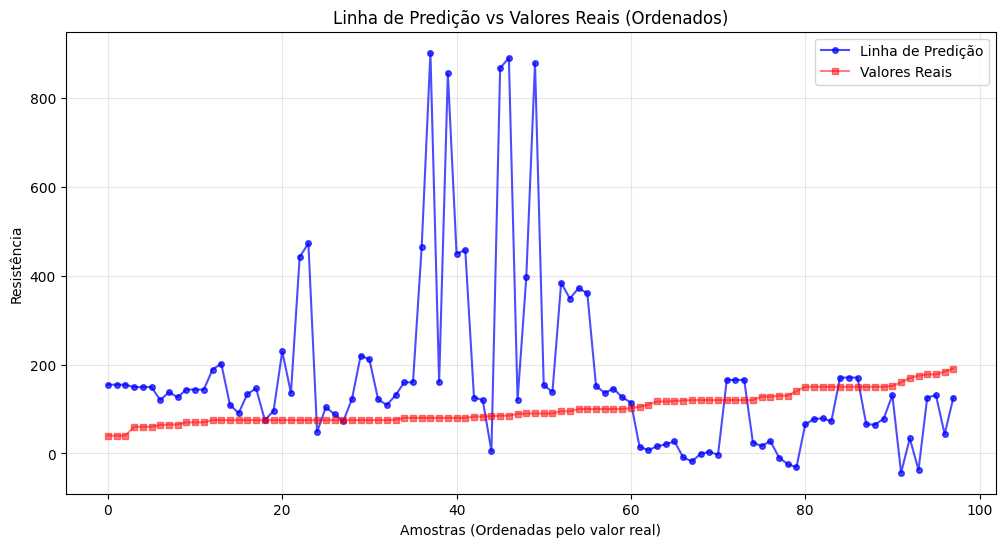

In [ ]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = lr_results.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição",
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais",
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Slump (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Distribuição dos residuos

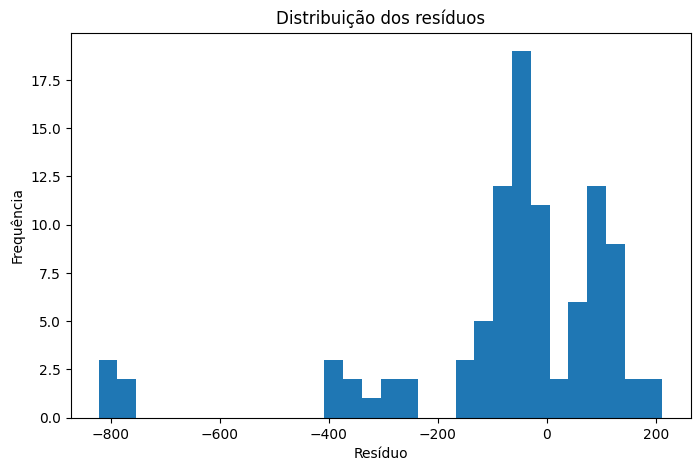

In [91]:
plt.figure(figsize=(8,5))

plt.hist(
    lr_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

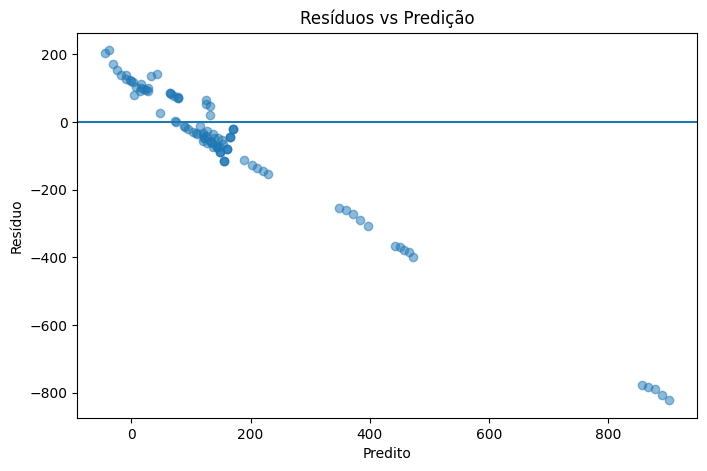

In [92]:
plt.figure(figsize=(8,5))

plt.scatter(
    lr_results["y_pred"],
    lr_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

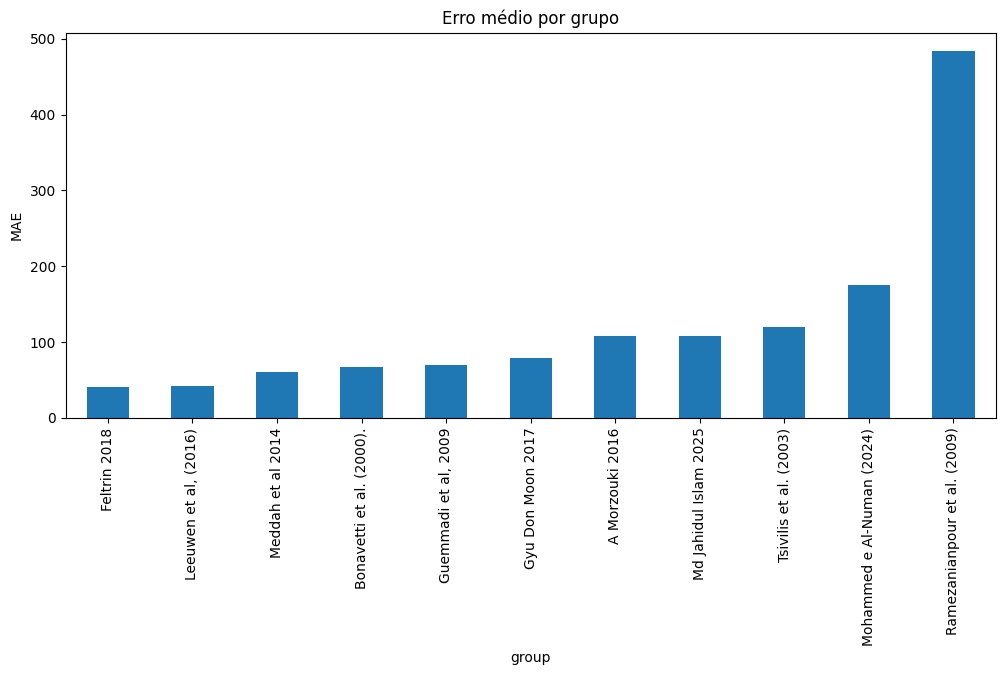

In [93]:
group_errors = (
    lr_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [94]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 224.4269
mean_absolute_error: 139.7574
mean_absolute_percentage_error: 1.5847
R² Score: -4031.2934


# Teste com regressão Lasso

In [95]:
X = df_lasso.drop(
    columns=["target", "Autores/ano"]
)

y = df_lasso["target"]
groups = df_lasso["Autores/ano"]

def objective(trial):
    rmse_scores = []

    alpha = trial.suggest_float("alpha", 10.0, 100.0)

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = Lasso(alpha=alpha, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [96]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 250

pbar = tqdm(total=n_trials, desc="Otimizando Regressão Lasso")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_lasso = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_lasso.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_lasso.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_lasso.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão Lasso:   0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-06-04 22:39:25,125] A new study created in memory with name: Tuning_Concreto
[I 2026-06-04 22:39:25,203] Trial 0 finished with value: 34.28520911205696 and parameters: {'alpha': 66.51616989357129}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:39:25,286] Trial 1 finished with value: 34.28520911205696 and parameters: {'alpha': 25.298502003856164}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:39:25,374] Trial 2 finished with value: 34.28520911205696 and parameters: {'alpha': 36.72011420910658}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:39:25,451] Trial 3 finished with value: 34.28520911205696 and parameters: {'alpha': 21.77599403063163}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:39:25,541] Trial 4 finished with value: 34.28520911205696 and parameters: {'alpha': 25.048837092139117}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:39:25,633] Trial 5 finished with value: 34.2852091120569

Melhor RMSE alcançado (Cross-Validation): 34.2852
Melhores Hiperparâmetros encontrados:
  'alpha': 66.51616989357129,


In [97]:
all_preds = []
all_true = []
all_groups = []

X = df_lasso.drop(
    columns=["target", "Autores/ano"]
)

y = df_lasso["target"]
groups = df_lasso["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = Lasso(alpha=study_lasso.best_params["alpha"], random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [98]:
lasso_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

lasso_results["residual"] = (
    lasso_results["y_true"] -
    lasso_results["y_pred"]
)

lasso_results["abs_error"] = (
    lasso_results["residual"].abs()
)

## Observado vs Predito

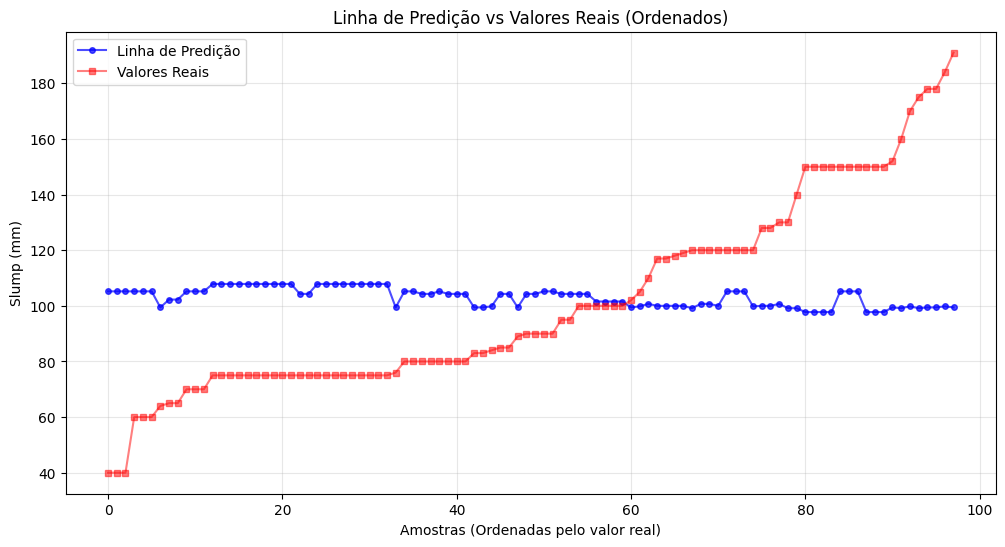

In [126]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = lasso_results.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição",
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais",
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Slump (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Distribuição dos residuos

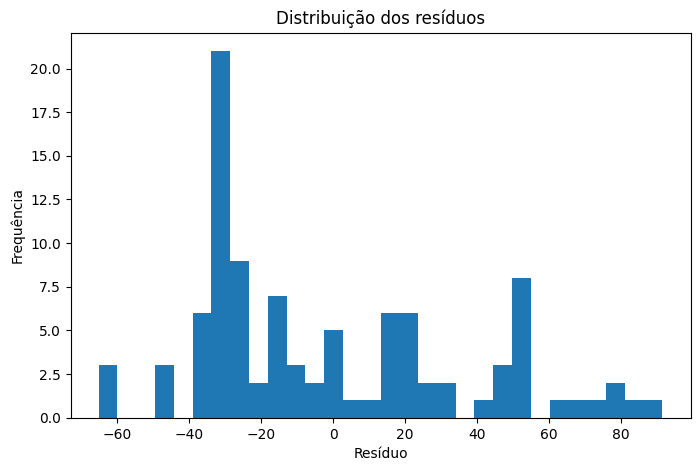

In [100]:
plt.figure(figsize=(8,5))

plt.hist(
    lasso_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

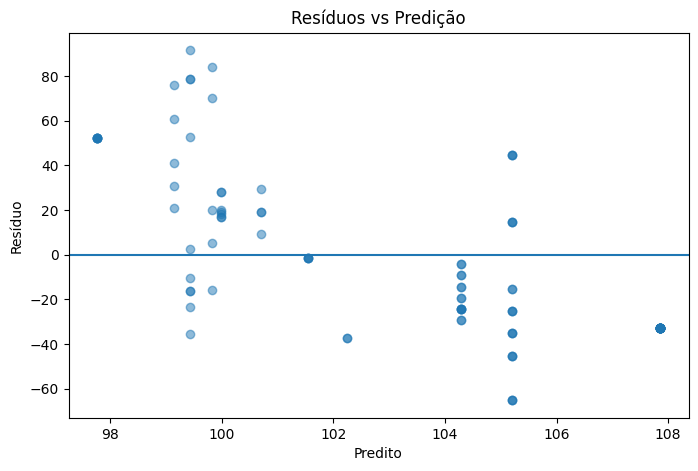

In [101]:
plt.figure(figsize=(8,5))

plt.scatter(
    lasso_results["y_pred"],
    lasso_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

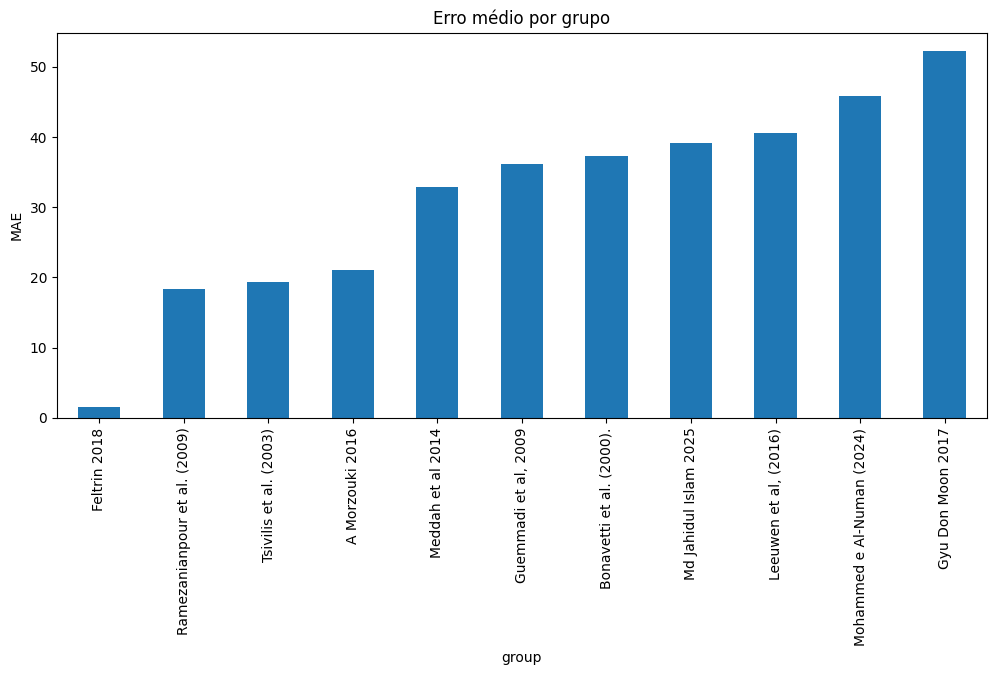

In [102]:
group_errors = (
    lasso_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [103]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 37.2755
mean_absolute_error: 31.8551
mean_absolute_percentage_error: 0.3497
R² Score: -13.9681


## Teste com regressão Ridge

In [104]:
X = df_ridge.drop(
    columns=["target", "Autores/ano"]
)

y = df_ridge["target"]
groups = df_ridge["Autores/ano"]

def objective(trial):
    rmse_scores = []

    alpha = trial.suggest_float("alpha", 1.0, 4e+22)

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = Ridge(alpha=alpha, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [105]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 100

pbar = tqdm(total=n_trials, desc="Otimizando Regressão Ridge")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_ridge = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_ridge.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_ridge.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_ridge.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão Ridge:   0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-04 22:39:50,434] A new study created in memory with name: Tuning_Concreto
[I 2026-06-04 22:39:50,534] Trial 0 finished with value: 34.28520911205696 and parameters: {'alpha': 3.0392342980121275e+22}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:39:50,623] Trial 1 finished with value: 34.28520911205696 and parameters: {'alpha': 1.1193749954530738e+22}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:39:50,710] Trial 2 finished with value: 34.28520911205696 and parameters: {'alpha': 1.0218563981947559e+22}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:39:50,795] Trial 3 finished with value: 34.28520911205696 and parameters: {'alpha': 3.924602932114488e+22}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:39:50,881] Trial 4 finished with value: 34.28520911205696 and parameters: {'alpha': 3.276608064576787e+22}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:39:50,968] Trial 5 finished with va

Melhor RMSE alcançado (Cross-Validation): 34.2852
Melhores Hiperparâmetros encontrados:
  'alpha': 3.0392342980121275e+22,


In [106]:
all_instances = []

X = df_ridge.drop(
    columns=["target", "Autores/ano"]
)

y = df_ridge["target"]
groups = df_ridge["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = Ridge(alpha=study_ridge.best_params["alpha"], random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    fold_results = df_ridge.iloc[val_idx].copy()

    fold_results["y_true"] = y_val.values
    fold_results["y_pred"] = preds
    fold_results["error"] = (
        fold_results["y_true"] - fold_results["y_pred"]
    )
    fold_results["abs_error"] = (
        fold_results["error"].abs()
    )
    fold_results["group"] = groups.iloc[val_idx].values

    all_instances.append(fold_results)

In [107]:
all_instances[0].columns

Index(['lubrificacao_efetiva', 'area_superficial_proxy', 'vol_areia',
       'indice_lubrificacao_global', 'fator_agua_finos',
       'potencial_segregacao', 'agua_sobre_areia', 'Agua_kg_m3', 'Autores/ano',
       'vol_cimento', 'vol_filer', 'Relacao_Agua_Aglomerante', 'vol_sp',
       'target', 'y_true', 'y_pred', 'error', 'abs_error', 'group'],
      dtype='object')

In [108]:
ridge_results = pd.concat(all_instances, ignore_index=True)

debug_df['error'] = (
    debug_df['y_true'] - debug_df['y_pred']
)

debug_df['abs_error'] = (
    debug_df['error'].abs()
)

ridge_results["residual"] = (
    ridge_results["y_true"] -
    ridge_results["y_pred"]
)

ridge_results["abs_error"] = (
    ridge_results["residual"].abs()
)

## Observado vs Predito

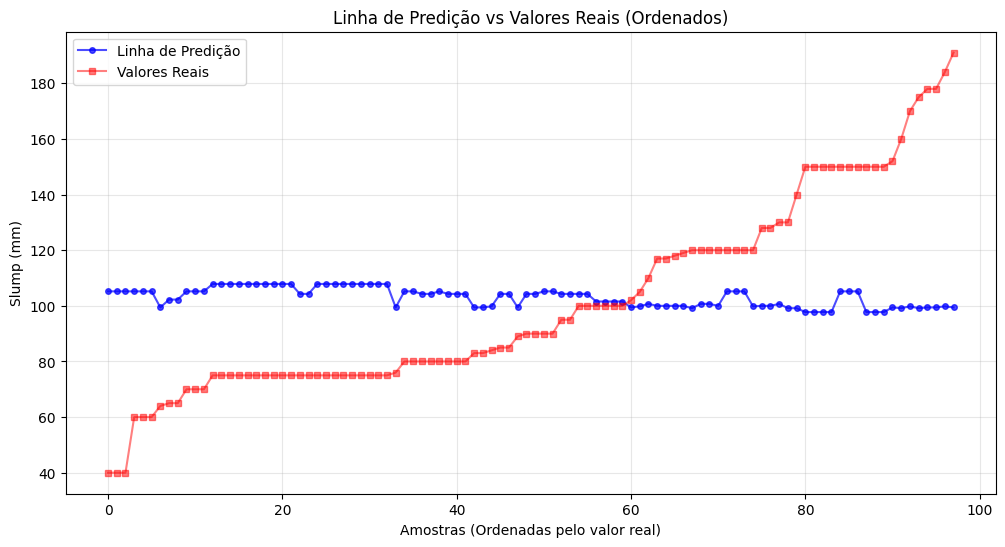

In [125]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = ridge_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição",
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais",
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Slump (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Distribuição dos residuos

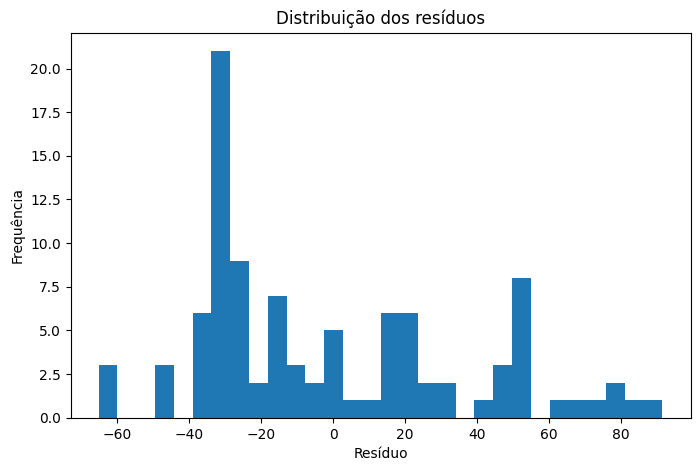

In [110]:
plt.figure(figsize=(8,5))

plt.hist(
    ridge_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

In [111]:
debug_df.columns

Index(['lubrificacao_efetiva', 'area_superficial_proxy', 'vol_areia',
       'indice_lubrificacao_global', 'fator_agua_finos',
       'potencial_segregacao', 'agua_sobre_areia', 'Agua_kg_m3', 'Autores/ano',
       'vol_cimento', 'vol_filer', 'Relacao_Agua_Aglomerante', 'vol_sp',
       'target', 'y_true', 'y_pred', 'error', 'abs_error', 'group',
       'residual'],
      dtype='object')

## Residuo vs Predito

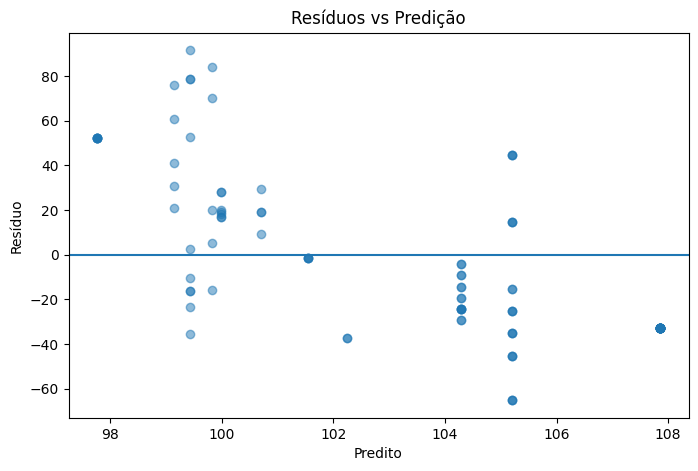

In [112]:
plt.figure(figsize=(8,5))

plt.scatter(
    ridge_results["y_pred"],
    ridge_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

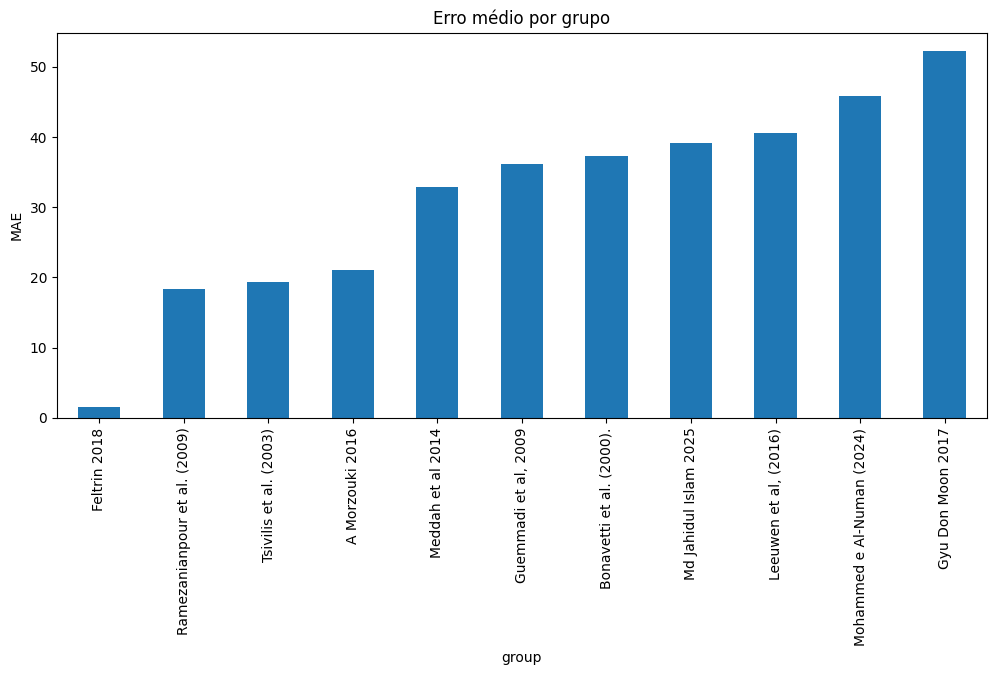

In [113]:
group_errors = (
    ridge_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [127]:
top_erros = (
    debug_df
    .query("abs_error > 40")
    .sort_values("abs_error", ascending=False)
)

display(top_erros)

,y_true,y_pred,group,residual,abs_error
97,191,99.431818,"Leeuwen et al, (2016)",91.568182,91.568182
96,184,99.817204,Md Jahidul Islam 2025,84.182796,84.182796
95,178,99.431818,"Leeuwen et al, (2016)",78.568182,78.568182
94,178,99.431818,"Leeuwen et al, (2016)",78.568182,78.568182
93,175,99.150538,Mohammed e Al-Numan (2024),75.849462,75.849462
92,170,99.817204,Md Jahidul Islam 2025,70.182796,70.182796
2,40,105.205128,"Guemmadi et al, 2009",-65.205128,65.205128
1,40,105.205128,"Guemmadi et al, 2009",-65.205128,65.205128
0,40,105.205128,"Guemmadi et al, 2009",-65.205128,65.205128
91,160,99.150538,Mohammed e Al-Numan (2024),60.849462,60.849462


In [115]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 37.2755
mean_absolute_error: 31.8551
mean_absolute_percentage_error: 0.3497
R² Score: -13.9681


## Teste com ElasticNet

In [116]:
X = df_elasticnet.drop(
    columns=["target", "Autores/ano"]
)

y = df_elasticnet["target"]
groups = df_elasticnet["Autores/ano"]

def objective(trial):
    rmse_scores = []

    hyperparams = {
        "alpha": trial.suggest_float("alpha", 10.0, 100.0),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0)
    }

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = ElasticNet(**hyperparams, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [117]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 100

pbar = tqdm(total=n_trials, desc="Otimizando Regressão ElasticNet")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_elasticnet = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_elasticnet.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_elasticnet.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_elasticnet.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão ElasticNet:   0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-04 22:40:03,740] A new study created in memory with name: Tuning_Concreto
[I 2026-06-04 22:40:03,845] Trial 0 finished with value: 34.28520911205696 and parameters: {'alpha': 73.23081806483414, 'l1_ratio': 0.9222846411482739}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:40:03,940] Trial 1 finished with value: 34.28520911205696 and parameters: {'alpha': 30.583148931998636, 'l1_ratio': 0.8984562042605917}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:40:04,041] Trial 2 finished with value: 34.42925166310532 and parameters: {'alpha': 59.886308551361985, 'l1_ratio': 0.10090579310079772}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:40:04,158] Trial 3 finished with value: 34.28520911205696 and parameters: {'alpha': 38.044258971905634, 'l1_ratio': 0.8473765197246831}. Best is trial 0 with value: 34.28520911205696.
[I 2026-06-04 22:40:04,260] Trial 4 finished with value: 34.28520911205696 and parameters: {'alpha': 79.5890444

Melhor RMSE alcançado (Cross-Validation): 34.2852
Melhores Hiperparâmetros encontrados:
  'alpha': 73.23081806483414,
  'l1_ratio': 0.9222846411482739,


In [118]:
all_preds = []
all_true = []
all_groups = []

X = df_elasticnet.drop(
    columns=["target", "Autores/ano"]
)

y = df_elasticnet["target"]
groups = df_elasticnet["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = ElasticNet(**study_elasticnet.best_params, random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [119]:
elasticnet_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

elasticnet_results["residual"] = (
    elasticnet_results["y_true"] -
    elasticnet_results["y_pred"]
)

elasticnet_results["abs_error"] = (
    elasticnet_results["residual"].abs()
)

## Observado vs Predito

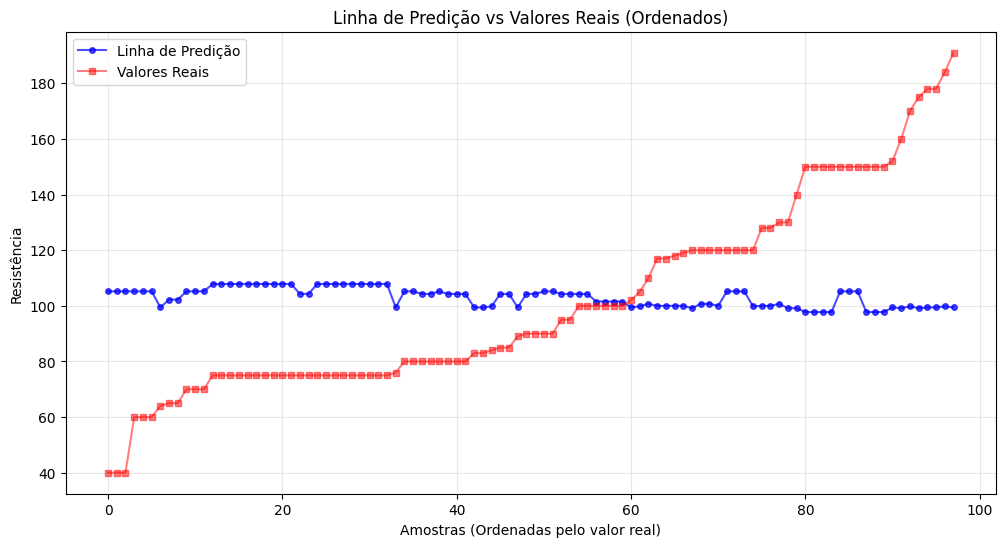

In [ ]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = elasticnet_results.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição",
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais",
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Slump (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Distribuição dos residuos

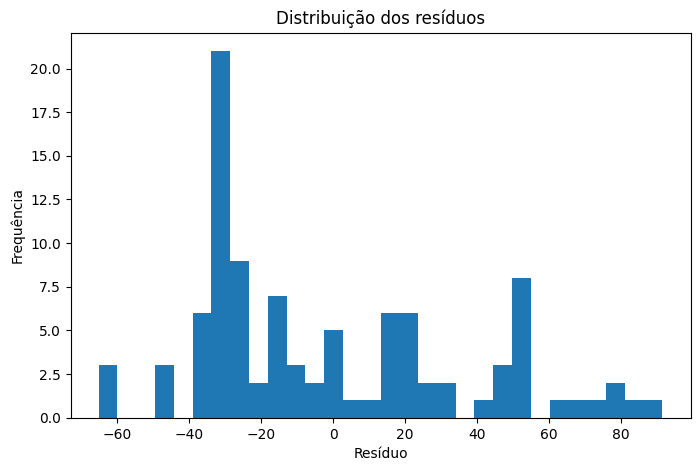

In [121]:
plt.figure(figsize=(8,5))

plt.hist(
    elasticnet_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

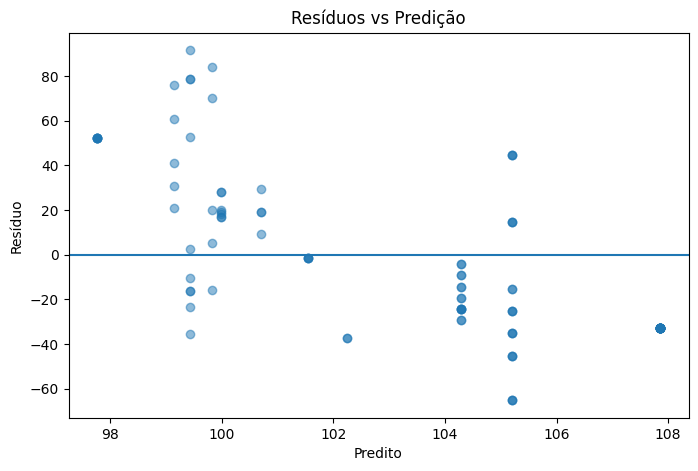

In [122]:
plt.figure(figsize=(8,5))

plt.scatter(
    elasticnet_results["y_pred"],
    elasticnet_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

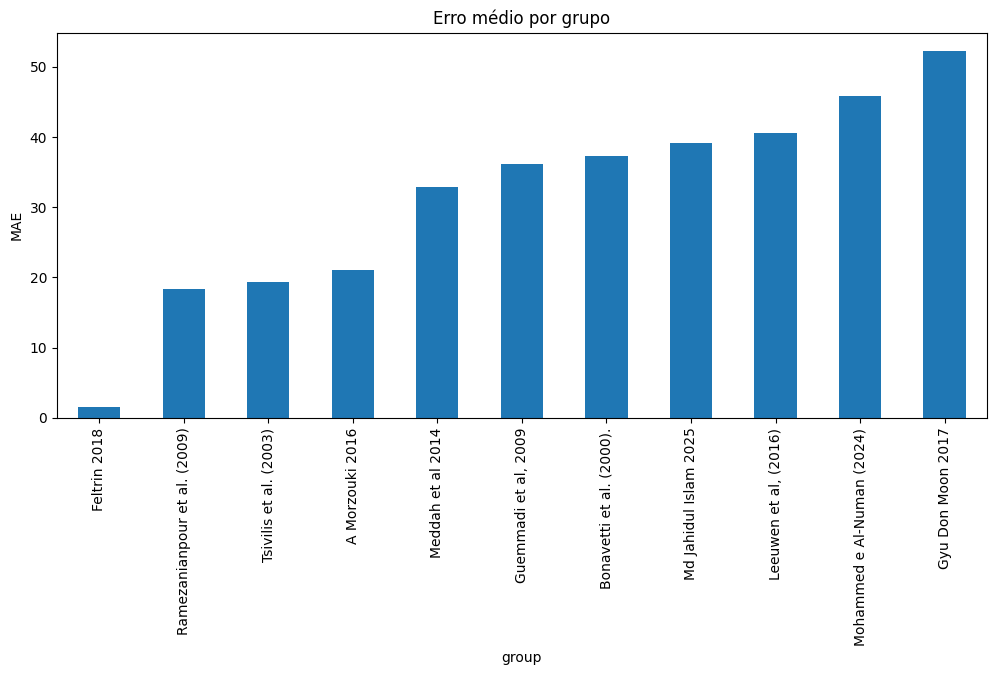

In [123]:
group_errors = (
    elasticnet_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [124]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 37.2755
mean_absolute_error: 31.8551
mean_absolute_percentage_error: 0.3497
R² Score: -13.9681
